# How Well Do Small Language Models Understand the Brazilian Educational Context?

**An Evaluation on ENEM, FUVEST and Unicamp**

This notebook consolidates every result available across the two source repositories and produces the figures and tables used in the paper.

> **Required folder layout.** This notebook reads data from two sibling repositories. Keep them next to this repo under the same parent directory:
>
> ```
> parent/
>   BRACIS-paper-ENEM-FUVEST-Unicamp/   <-- this repo
>   BLUEX/                               <-- FUVEST + UNICAMP results
>   ENEM-question-answering/             <-- ENEM results
> ```
>
> The first cell below asserts that both sibling folders are present and aborts with a clear message otherwise.

## Sections

1. Setup and configuration
2. Datasets overview
3. Methodology recap
4. Overall accuracy per dataset
5. Per-subject performance
6. Per-year evolution
7. Capability and modality analysis
8. Cost–benefit analysis
9. VLM descriptor sensitivity
10. Cross-dataset summary and best-SLM spotlight
11. Failure analysis
12. Artifacts appendix

## 1. Setup and configuration

Imports, sibling-folder path resolution, publication-style matplotlib defaults, the `save_fig` helper, and the SLM-vs-larger-model classification.

In [1]:
from __future__ import annotations

import json
import sqlite3
import sys
import warnings
from pathlib import Path
import dotenv

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

PARENT_DIR = REPO_ROOT.parent
BLUEX_DIR = PARENT_DIR / "BLUEX"
ENEM_DIR = PARENT_DIR / "ENEM-question-answering"

FIGURES_DIR = REPO_ROOT / "figures"
TABLES_DIR = REPO_ROOT / "tables"
FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

# Make `experiments` importable so we can reuse the dataclasses + loaders.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SQLITE_PATH = REPO_ROOT / "experiments" / "data" / "results.sqlite"
if not SQLITE_PATH.exists():
    raise FileNotFoundError(
        f"Missing {SQLITE_PATH}.\n"
        "Run plan-3 first:\n"
        "  python -m experiments.runner --plan   # cost forecast\n"
        "  python -m experiments.runner          # the actual run"
    )

_missing = [p for p in (BLUEX_DIR, ENEM_DIR) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "Missing sibling repositories: "
        + ", ".join(str(p) for p in _missing)
        + "\n\nThis notebook expects the following layout:\n"
        f"  {PARENT_DIR}/\n"
        f"    BRACIS-paper-ENEM-FUVEST-Unicamp/  (this repo, at {REPO_ROOT})\n"
        f"    BLUEX/\n"
        f"    ENEM-question-answering/\n"
        "(the sibling repos are still needed because `experiments.datasets` "
        "loads the BLUEX BNCC capability flags directly from the BLUEX JSONs.)"
    )

print(f"Repo root:    {REPO_ROOT}")
print(f"BLUEX dir:    {BLUEX_DIR}")
print(f"ENEM dir:     {ENEM_DIR}")
print(f"SQLite path:  {SQLITE_PATH}")
print(f"Figures ->    {FIGURES_DIR}")
print(f"Tables  ->    {TABLES_DIR}")

Repo root:    C:\Users\gmlem\Documents\IC - KG4AI\BRACIS-paper-ENEM-FUVEST-Unicamp
BLUEX dir:    C:\Users\gmlem\Documents\IC - KG4AI\BLUEX
ENEM dir:     C:\Users\gmlem\Documents\IC - KG4AI\ENEM-question-answering
SQLite path:  C:\Users\gmlem\Documents\IC - KG4AI\BRACIS-paper-ENEM-FUVEST-Unicamp\experiments\data\results.sqlite
Figures ->    C:\Users\gmlem\Documents\IC - KG4AI\BRACIS-paper-ENEM-FUVEST-Unicamp\figures
Tables  ->    C:\Users\gmlem\Documents\IC - KG4AI\BRACIS-paper-ENEM-FUVEST-Unicamp\tables


In [10]:
sns.set_theme(context="paper", style="whitegrid", palette="Greys")
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

SLM_COLOR = "#1f77b4"
LARGE_COLOR = "#d62728"
SLM_HATCH = ""
LARGE_HATCH = "//"


def save_fig(fig, name: str) -> None:
    """Save a figure as both PDF (paper) and PNG (preview) under figures/."""
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    png_path = FIGURES_DIR / f"{name}.png"
    fig.savefig(pdf_path)
    fig.savefig(png_path)
    print(f"  saved figures/{name}.pdf and figures/{name}.png")


def save_table(df: pd.DataFrame, name: str) -> None:
    path = TABLES_DIR / f"{name}.csv"
    df.to_csv(path, index=True if df.index.name else False)
    print(f"  saved tables/{name}.csv  ({len(df)} rows)")

### 1.1 Small Language Model classification

The literature does not give a single hard cutoff for what counts as a *Small Language Model*; recent surveys (e.g. Lu et al., 2024 — *A Survey of Small Language Models*; the Phi technical reports; Microsoft Research's SLM definition) typically place the boundary at roughly **≤ 7–14 B parameters** for dense models and use *active* parameter count for Mixture-of-Experts. We adopt **≤ 14 B active parameters** as the SLM threshold and additionally flag MoE models with low active-parameter count as SLM-class.

Models above the threshold are kept as **reference larger models** so that we can quantify how far SLMs are from them. The 2026 fleet now includes GLM-5.1 as the state-of-the-art open-weight reference used to measure the remaining gap between SLM-class models and the current frontier.

The classification below is configurable: change the `is_slm` flag in `MODEL_INFO` to re-label any model and re-run the notebook.

In [3]:
# DeepInfra $/1M tokens (Apr 2026). Mirrors `models.json`; keep in sync.
# `experiments.config.load_models()` is the canonical source; we duplicate
# here only for the legacy plot helpers that look up cost / params_b / is_slm
# by full name.
MODEL_INFO: dict[str, dict] = {
    "google/gemma-3-4b-it":                       {"short": "gemma-3-4b-it",                "params_b": 4.0,    "is_slm": True,  "moe": False, "cost_per_m_input_usd": 0.04,  "cost_per_m_output_usd": 0.08},
    "google/gemma-3-12b-it":                      {"short": "gemma-3-12b-it",               "params_b": 12.0,   "is_slm": True,  "moe": False, "cost_per_m_input_usd": 0.04,  "cost_per_m_output_usd": 0.13},
    "google/gemma-3-27b-it":                      {"short": "gemma-3-27b-it",               "params_b": 27.0,   "is_slm": False, "moe": False, "cost_per_m_input_usd": 0.08,  "cost_per_m_output_usd": 0.16},
    "google/gemma-4-31B-it":                      {"short": "gemma-4-31B-it",               "params_b": 31.0,   "is_slm": False, "moe": False, "cost_per_m_input_usd": 0.13,  "cost_per_m_output_usd": 0.38},
    "meta-llama/Meta-Llama-3.1-8B-Instruct":      {"short": "Meta-Llama-3.1-8B-Instruct",   "params_b": 8.0,    "is_slm": True,  "moe": False, "cost_per_m_input_usd": 0.02,  "cost_per_m_output_usd": 0.05},
    "Qwen/Qwen3.5-0.8B":                          {"short": "Qwen3.5-0.8B",                 "params_b": 0.8,    "is_slm": True,  "moe": True,  "cost_per_m_input_usd": 0.01,  "cost_per_m_output_usd": 0.05},
    "Qwen/Qwen3.5-2B":                            {"short": "Qwen3.5-2B",                   "params_b": 2.0,    "is_slm": True,  "moe": False, "cost_per_m_input_usd": 0.02,  "cost_per_m_output_usd": 0.10},
    "Qwen/Qwen3.5-4B":                            {"short": "Qwen3.5-4B",                   "params_b": 4.0,    "is_slm": True,  "moe": False, "cost_per_m_input_usd": 0.03,  "cost_per_m_output_usd": 0.15},
    "meta-llama/Llama-3.3-70B-Instruct-Turbo":    {"short": "Llama-3.3-70B-Instruct-Turbo", "params_b": 70.0,   "is_slm": False, "moe": False, "cost_per_m_input_usd": 0.10,  "cost_per_m_output_usd": 0.32},
    "deepseek-ai/DeepSeek-V4-Flash":              {"short": "DeepSeek-V4-Flash",            "params_b": 284.0,  "is_slm": False, "moe": True,  "active_params_b": 13.0, "cost_per_m_input_usd": 0.14,  "cost_per_m_output_usd": 0.28, "cost_per_m_cached_usd": 0.028},
    "deepseek-ai/DeepSeek-V3.2":                  {"short": "DeepSeek-V3.2",                "params_b": 671.0,  "is_slm": False, "moe": True,  "active_params_b": 37.0, "cost_per_m_input_usd": 0.26,  "cost_per_m_output_usd": 0.38, "cost_per_m_cached_usd": 0.13},
    # Disabled to keep the SOTA comparison near the $10 budget.
    # "deepseek-ai/DeepSeek-V4-Pro":              {"short": "DeepSeek-V4-Pro",              "params_b": 1600.0, "is_slm": False, "moe": True,  "active_params_b": 49.0, "cost_per_m_input_usd": 1.74,  "cost_per_m_output_usd": 3.48, "cost_per_m_cached_usd": 0.145},
    # "moonshotai/Kimi-K2.6":                     {"short": "Kimi-K2.6",                    "params_b": 1000.0, "is_slm": False, "moe": True,  "active_params_b": 32.0, "cost_per_m_input_usd": 0.75,  "cost_per_m_output_usd": 3.50, "cost_per_m_cached_usd": 0.15},
    "zai-org/GLM-5.1":                            {"short": "GLM-5.1",                      "params_b": 754.0,  "is_slm": False, "moe": True,  "active_params_b": 40.0, "cost_per_m_input_usd": 1.05,  "cost_per_m_output_usd": 3.50, "cost_per_m_cached_usd": 0.205},
}

MODEL_DF = (
    pd.DataFrame.from_dict(MODEL_INFO, orient="index")
    .rename_axis("modelo")
    .reset_index()
)
SHORT_TO_FULL = {v["short"]: k for k, v in MODEL_INFO.items()}


def model_short(full_name: str) -> str:
    return MODEL_INFO.get(full_name, {}).get("short", full_name.split("/")[-1])


def is_slm(name: str) -> bool:
    if name in MODEL_INFO:
        return MODEL_INFO[name]["is_slm"]
    if name in SHORT_TO_FULL:
        return MODEL_INFO[SHORT_TO_FULL[name]]["is_slm"]
    return False


def model_color(name: str) -> str:
    return SLM_COLOR if is_slm(name) else LARGE_COLOR


def model_hatch(name: str) -> str:
    return SLM_HATCH if is_slm(name) else LARGE_HATCH


display(MODEL_DF.sort_values(["is_slm", "params_b"], ascending=[False, True]).reset_index(drop=True))

,modelo,short,params_b,is_slm,moe,cost_per_m_input_usd,cost_per_m_output_usd,active_params_b,cost_per_m_cached_usd
0,Qwen/Qwen3.5-0.8B,Qwen3.5-0.8B,0.8,True,True,0.01,0.05,NaN,NaN
1,Qwen/Qwen3.5-2B,Qwen3.5-2B,2.0,True,False,0.02,0.10,NaN,NaN
2,google/gemma-3-4b-it,gemma-3-4b-it,4.0,True,False,0.04,0.08,NaN,NaN
3,Qwen/Qwen3.5-4B,Qwen3.5-4B,4.0,True,False,0.03,0.15,NaN,NaN
4,meta-llama/Meta-Llama-3.1-8B-Instruct,Meta-Llama-3.1-8B-Instruct,8.0,True,False,0.02,0.05,NaN,NaN
5,google/gemma-3-12b-it,gemma-3-12b-it,12.0,True,False,0.04,0.13,NaN,NaN
6,google/gemma-3-27b-it,gemma-3-27b-it,27.0,False,False,0.08,0.16,NaN,NaN
7,google/gemma-4-31B-it,gemma-4-31B-it,31.0,False,False,0.13,0.38,NaN,NaN
8,meta-llama/Llama-3.3-70B-Instruct-Turbo,Llama-3.3-70B-Instruct-Turbo,70.0,False,False,0.10,0.32,NaN,NaN
9,deepseek-ai/DeepSeek-V4-Flash,DeepSeek-V4-Flash,284.0,False,True,0.14,0.28,13.0,0.028


## 2. Datasets overview

ENEM, FUVEST and Unicamp share a common pipeline (see Section 3) but differ in scale, year coverage and modality balance. The table below counts unique questions, year coverage and the share of image-augmented items per dataset.

- **ENEM** counts come from `outputs/slm-benchmark/runs/slm-benchmark-v1/run.meta.json` and per-question CSV.
- **FUVEST / Unicamp** counts come from any single per-model file in `BLUEX/results/descriptions/` (one row per question per model), filtered by the `university` column.

In [4]:
from experiments import config as _exp_config, datasets as _exp_datasets

FUVEST_KEY = "FUVEST"
UNICAMP_KEY = "UNICAMP"
UNIVERSITY_DISPLAY = {"ENEM": "ENEM", FUVEST_KEY: "FUVEST", UNICAMP_KEY: "Unicamp"}


def load_results() -> pd.DataFrame:
    """Read every row from `experiments/data/results.sqlite`."""
    with sqlite3.connect(str(SQLITE_PATH)) as conn:
        df = pd.read_sql("SELECT * FROM results", conn)
    df["has_images"] = df["has_images"].astype(bool)
    df["images_in_alt"] = df["images_in_alt"].astype(bool)
    df["is_correct_bool"] = df["is_correct"].apply(
        lambda v: bool(v) if v in (0, 1) else None
    )
    df["subject_list"] = df["subject"].apply(
        lambda s: json.loads(s) if isinstance(s, str) and s else []
    )
    df["model_short"] = df["model"].map(model_short)
    df["is_slm"] = df["model"].map(is_slm)
    return df


def load_questions_df() -> pd.DataFrame:
    """Build a per-question metadata frame including BLUEX BNCC capability flags."""
    qs = _exp_datasets.load_all_questions()
    rows = []
    for q in qs:
        rows.append({
            "question_id": q.question_id,
            "dataset": q.dataset,
            "year": q.year,
            "subject": list(q.subject),
            "alternatives_type": q.alternatives_type,
            "has_images": bool(q.has_images),
            "images_in_alt": bool(q.images_in_alternatives),
            "cap_BK": bool(q.cap_BK),
            "cap_TU": bool(q.cap_TU),
            "cap_MR": bool(q.cap_MR),
            "cap_IU": bool(q.cap_IU),
            "cap_ML": bool(q.cap_ML),
            "cap_PRK": bool(q.cap_PRK),
            "cap_CI": bool(q.cap_CI),
        })
    return pd.DataFrame(rows)


# Identify the most-recent production run id (largest finished_at). Older
# rows from plan-2's smoke test stay in `RESULTS` but are flagged in §12.
def _detect_production_run_id() -> str | None:
    with sqlite3.connect(str(SQLITE_PATH)) as conn:
        cur = conn.execute(
            """
            SELECT run_id, COUNT(*) AS n
            FROM results
            WHERE run_id IS NOT NULL
            GROUP BY run_id
            ORDER BY n DESC
            LIMIT 1
            """
        )
        row = cur.fetchone()
    return row[0] if row else None


RESULTS = load_results()
QUESTIONS = load_questions_df()
PRODUCTION_RUN_ID = _detect_production_run_id()

print(
    f"RESULTS rows: {len(RESULTS):,} | unique questions: "
    f"{RESULTS['question_id'].nunique():,} | unique models: "
    f"{RESULTS['model'].nunique()} | datasets: "
    f"{sorted(RESULTS['dataset'].unique().tolist())}"
)
print(
    f"QUESTIONS rows: {len(QUESTIONS):,} | datasets: "
    f"{QUESTIONS['dataset'].value_counts().to_dict()}"
)
print(f"Production run id (most-rows): {PRODUCTION_RUN_ID}")

RESULTS rows: 44,520 | unique questions: 3,710 | unique models: 12 | datasets: ['ENEM', 'FUVEST', 'UNICAMP']
QUESTIONS rows: 3,710 | datasets: {'ENEM': 2595, 'FUVEST': 630, 'UNICAMP': 485}
Production run id (most-rows): 20260427T114347Z


In [5]:
def _overview_row(dataset: str) -> dict:
    q = QUESTIONS[QUESTIONS["dataset"] == dataset]
    if q.empty:
        return {
            "dataset": UNIVERSITY_DISPLAY.get(dataset, dataset),
            "questions": 0,
            "years_min": np.nan,
            "years_max": np.nan,
            "n_years": 0,
            "n_subjects": 0,
            "image_augmented_pct": float("nan"),
        }
    subjects = q["subject"].explode().dropna().astype(str).str.strip()
    subjects = subjects[subjects != ""]
    return {
        "dataset": UNIVERSITY_DISPLAY.get(dataset, dataset),
        "questions": int(q["question_id"].nunique()),
        "years_min": int(q["year"].min()),
        "years_max": int(q["year"].max()),
        "n_years": int(q["year"].nunique()),
        "n_subjects": int(subjects.nunique()),
        "image_augmented_pct": 100.0 * float(q["has_images"].mean()),
    }


overview_rows = [_overview_row(d) for d in ("ENEM", FUVEST_KEY, UNICAMP_KEY)]
DATASETS_OVERVIEW = pd.DataFrame(overview_rows).set_index("dataset")
DATASETS_OVERVIEW["image_augmented_pct"] = DATASETS_OVERVIEW["image_augmented_pct"].round(1)
DATASETS_OVERVIEW["years_range"] = DATASETS_OVERVIEW.apply(
    lambda r: f"{int(r['years_min'])}–{int(r['years_max'])}" if pd.notna(r["years_min"]) else "n/a",
    axis=1,
)
DATASETS_OVERVIEW = DATASETS_OVERVIEW[["questions", "years_range", "n_years", "n_subjects", "image_augmented_pct"]]
DATASETS_OVERVIEW.columns = ["#questions", "years", "#years", "#subjects", "%image-aug."]

save_table(DATASETS_OVERVIEW, "datasets_overview")
DATASETS_OVERVIEW

  saved tables/datasets_overview.csv  (3 rows)


,#questions,years,#years,#subjects,%image-aug.
dataset,,,,,
ENEM,2595,2009–2023,15,4,39.5
FUVEST,630,2018–2024,7,9,46.2
Unicamp,485,2018–2024,6,9,40.6


## 3. Methodology recap

All experiments use a two-stage **description-based pipeline**:

1. For every question that contains images, a Vision-Language Model (the **descriptor**) generates a Portuguese textual description of the image. Text-only questions skip this step.
2. A language model (the **answerer**) receives the question text together with the descriptor's output and must return a single letter (A–E for ENEM; A–E or *true/false* for FUVEST/Unicamp).

This pipeline lets us evaluate text-only SLMs on multimodal exams and isolates two sources of error: the descriptor's faithfulness and the answerer's reasoning. The main target is the SLM fleet, while larger and state-of-the-art open-weight answerers are retained as reference points for the SLM-to-frontier gap.

- **Answerer models** — listed in Section 1.1, with SLMs plus larger references including GLM-5.1.
- **Descriptors** — eleven VLMs in BLUEX (Seed-1.8, Seed-2.0-mini, Qwen3-VL-235B, Qwen3-VL-30B, gemma-3-{4,12,27}b-it, Llama-3.2-11B-Vision, Llama-4-Maverick, Llama-4-Scout, Mistral-Small-3.2-24B) and the same family in ENEM (`by_vision_model.csv`).

Refer to the source notebooks for full pipeline details: `ENEM-question-answering/notebooks/enem_slm_benchmark.ipynb` and `BLUEX/run_descriptions.ipynb`.

## 4. Overall accuracy per dataset

For each dataset we plot every model's overall accuracy. SLMs are drawn in solid blue bars; reference larger models are drawn in red with a hatch pattern, so the visual separation survives grayscale printing.

- **ENEM**: from `analysis/slm-benchmark-v1/executive_by_model.csv`.
- **FUVEST / Unicamp**: re-computed from `BLUEX/results/descriptions/*.csv` by averaging `is_correct` per `(modelo, university)` (i.e. averaged over all descriptors).

In [6]:
def overall(dataset: str) -> pd.DataFrame:
    """Per-model overall accuracy for one dataset, computed from RESULTS.

    Models that returned no parsed answer at all are dropped (they hit
    `model_unavailable` or `cost_cap_reached` for every pair); they show
    up in §12 instead.
    """
    df = RESULTS[RESULTS["dataset"] == dataset]
    if df.empty:
        return pd.DataFrame(columns=[
            "modelo", "model_short", "is_slm", "accuracy_pct",
            "n_rows", "n_parsed", "tasks_observed", "total_cost_usd", "total_cost",
        ])
    grp = (
        df.groupby(["model", "model_short", "is_slm"], dropna=False)
        .agg(
            n_rows=("question_id", "count"),
            n_parsed=("parsed_answer", lambda s: int(s.notna().sum())),
            n_correct=("is_correct", lambda s: int((s == 1).sum())),
            total_cost=("cost_usd", "sum"),
        )
        .reset_index()
        .rename(columns={"model": "modelo"})
    )
    grp["accuracy_pct"] = np.where(
        grp["n_parsed"] > 0,
        100.0 * grp["n_correct"] / grp["n_parsed"],
        np.nan,
    )
    grp = grp.dropna(subset=["accuracy_pct"]).copy()
    # Aliases kept for legacy plotting helpers below.
    grp["tasks_observed"] = grp["n_parsed"]
    grp["total_cost_usd"] = grp["total_cost"]
    return grp.sort_values("accuracy_pct", ascending=False).reset_index(drop=True)


ENEM_OVERALL = overall("ENEM")
FUVEST_OVERALL = overall(FUVEST_KEY)
UNICAMP_OVERALL = overall(UNICAMP_KEY)
BLUEX_OVERALL_ALL = (
    pd.concat([FUVEST_OVERALL, UNICAMP_OVERALL], ignore_index=True)
    .sort_values("accuracy_pct", ascending=False)
    .reset_index(drop=True)
)

save_table(ENEM_OVERALL, "overall_accuracy_enem")
save_table(FUVEST_OVERALL, "overall_accuracy_fuvest")
save_table(UNICAMP_OVERALL, "overall_accuracy_unicamp")

  saved tables/overall_accuracy_enem.csv  (12 rows)
  saved tables/overall_accuracy_fuvest.csv  (12 rows)
  saved tables/overall_accuracy_unicamp.csv  (12 rows)


  saved figures/overall_accuracy_enem.pdf and figures/overall_accuracy_enem.png


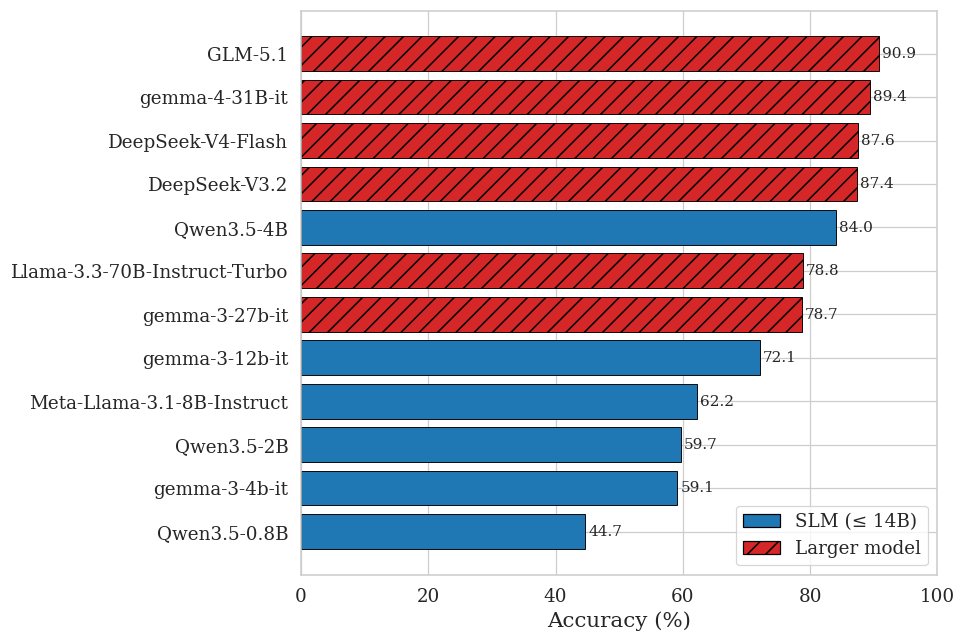

  saved figures/overall_accuracy_fuvest.pdf and figures/overall_accuracy_fuvest.png


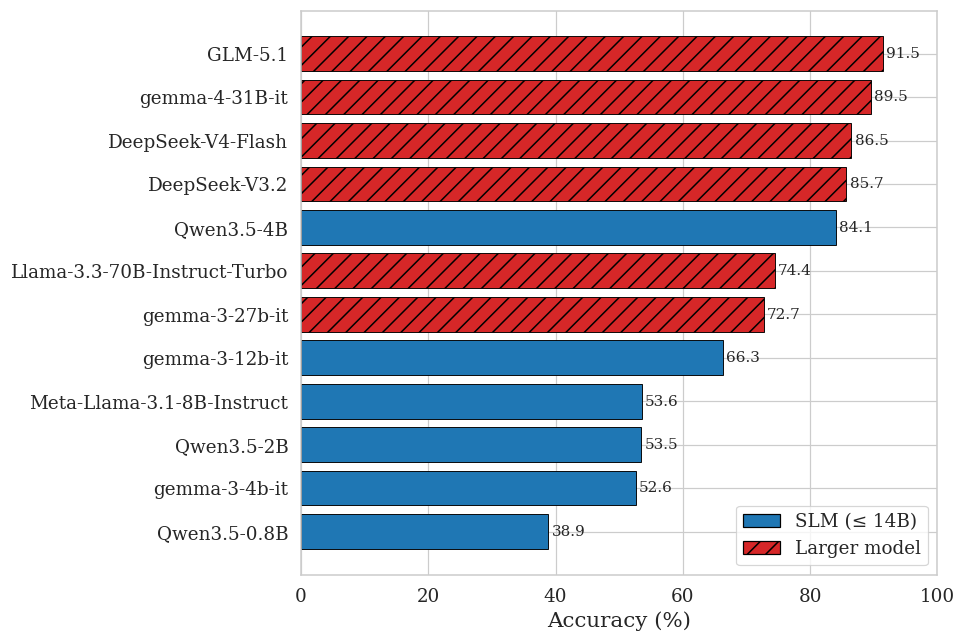

  saved figures/overall_accuracy_unicamp.pdf and figures/overall_accuracy_unicamp.png


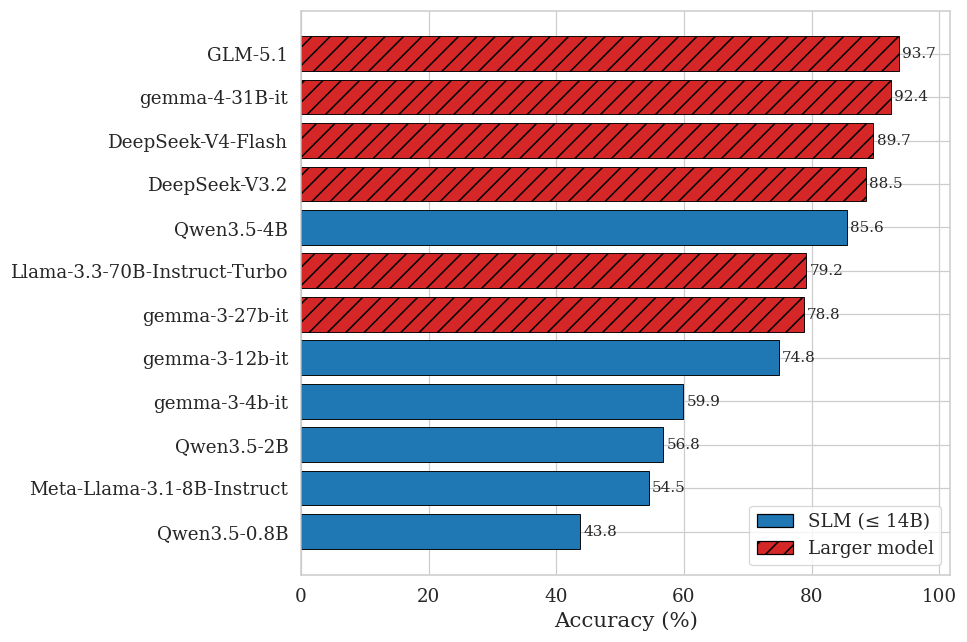

In [7]:
def plot_overall_bar(df: pd.DataFrame, title: str, fig_name: str) -> None:
    df = df.sort_values("accuracy_pct", ascending=True).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9.0, max(3.5, 0.38 * len(df) + 1.5)))
    colors = [SLM_COLOR if s else LARGE_COLOR for s in df["is_slm"]]
    hatches = [SLM_HATCH if s else LARGE_HATCH for s in df["is_slm"]]
    bars = ax.barh(df["model_short"], df["accuracy_pct"], color=colors, edgecolor="black", linewidth=0.6)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    for bar, val in zip(bars, df["accuracy_pct"]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", fontsize=10)
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, max(100, df["accuracy_pct"].max() + 8))
    slm_handle = mpl.patches.Patch(facecolor=SLM_COLOR, edgecolor="black", label="SLM (\u2264 14B)")
    large_handle = mpl.patches.Patch(facecolor=LARGE_COLOR, edgecolor="black", hatch=LARGE_HATCH, label="Larger model")
    ax.legend(handles=[slm_handle, large_handle], loc="lower right", frameon=True)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


plot_overall_bar(ENEM_OVERALL,    "Overall accuracy on ENEM",    "overall_accuracy_enem")
plot_overall_bar(FUVEST_OVERALL,  "Overall accuracy on FUVEST",  "overall_accuracy_fuvest")
plot_overall_bar(UNICAMP_OVERALL, "Overall accuracy on Unicamp", "overall_accuracy_unicamp")

## 5. Per-subject performance

Heatmaps of accuracy (%) per model × subject, one per dataset. Models are sorted by overall accuracy on the dataset to make patterns easier to read. All three datasets are computed the same way: join `RESULTS` with `QUESTIONS` on `question_id`, explode the `subject` list, and take the mean of `is_correct` per `(model_short, subject)`.

In [11]:
def subject_pivot(dataset: str) -> pd.DataFrame:
    """Accuracy (%) per (model_short × subject) for one dataset.

    Joins RESULTS with QUESTIONS on `question_id`, explodes the subject
    list, and pivots. Models are ordered by overall accuracy on the dataset
    so the heatmap reads top-down.
    """
    res = RESULTS[RESULTS["dataset"] == dataset][
        ["question_id", "model_short", "is_correct"]
    ]
    if res.empty:
        return pd.DataFrame()
    qs = QUESTIONS[QUESTIONS["dataset"] == dataset][["question_id", "subject"]]
    merged = res.merge(qs, on="question_id", how="inner")
    merged = merged.explode("subject")
    merged = merged[merged["subject"].notna() & (merged["subject"] != "")]
    merged["subject_clean"] = merged["subject"].astype(str).str.title()
    merged = merged.dropna(subset=["is_correct"])
    pivot = (
        merged.groupby(["model_short", "subject_clean"])["is_correct"]
        .mean()
        .unstack("subject_clean") * 100
    )
    order_df = {
        "ENEM": ENEM_OVERALL,
        FUVEST_KEY: FUVEST_OVERALL,
        UNICAMP_KEY: UNICAMP_OVERALL,
    }.get(dataset)
    if order_df is not None and not order_df.empty:
        order = order_df.set_index("model_short")["accuracy_pct"]
        pivot = pivot.reindex(order.sort_values(ascending=False).index.intersection(pivot.index))
    return pivot


def enem_subject_pivot() -> pd.DataFrame:
    return subject_pivot("ENEM")


def bluex_subject_pivot(university: str) -> pd.DataFrame:
    return subject_pivot(university)

  saved tables/subject_heatmap_enem.csv  (12 rows)
  saved tables/subject_heatmap_fuvest.csv  (12 rows)
  saved tables/subject_heatmap_unicamp.csv  (12 rows)
  saved tables/subject_heatmap_bluex.csv  (12 rows)
  saved figures/subject_heatmap_enem.pdf and figures/subject_heatmap_enem.png


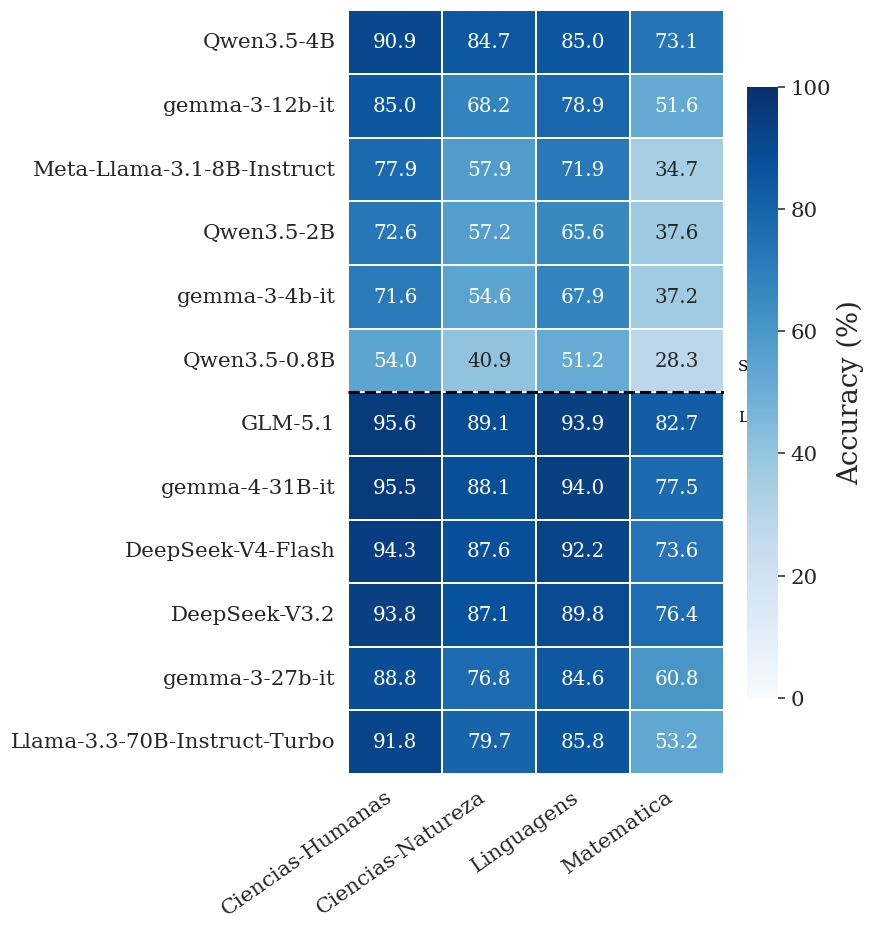

  saved figures/subject_heatmap_fuvest.pdf and figures/subject_heatmap_fuvest.png


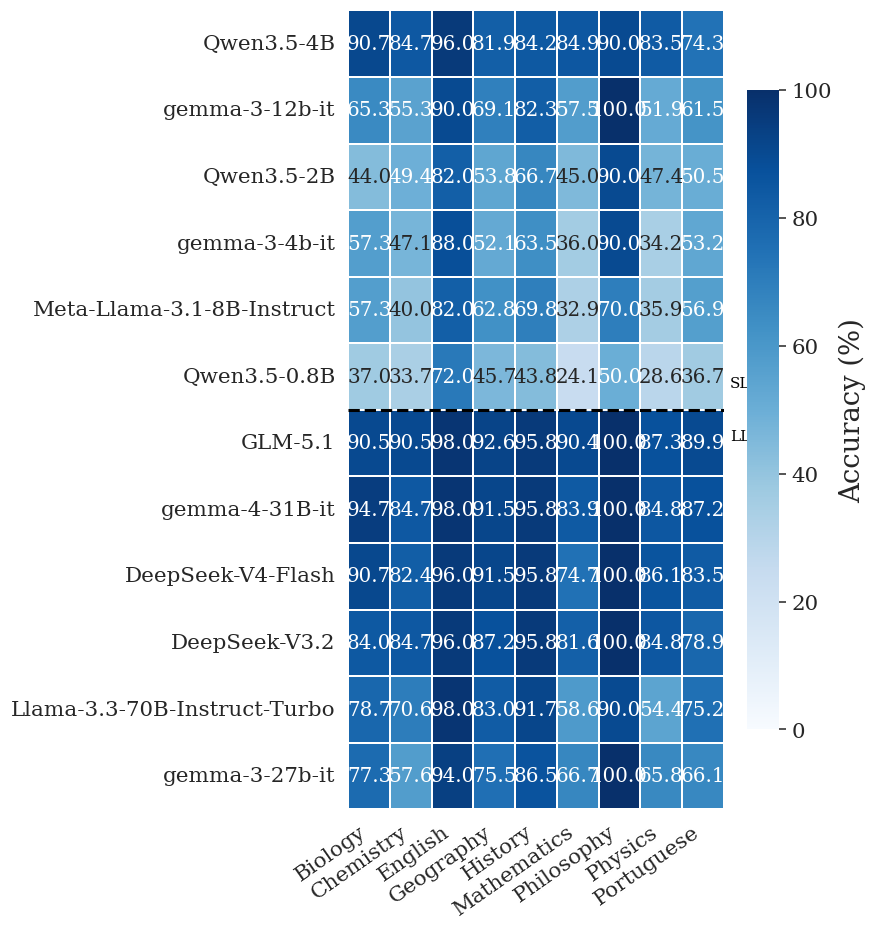

  saved figures/subject_heatmap_unicamp.pdf and figures/subject_heatmap_unicamp.png


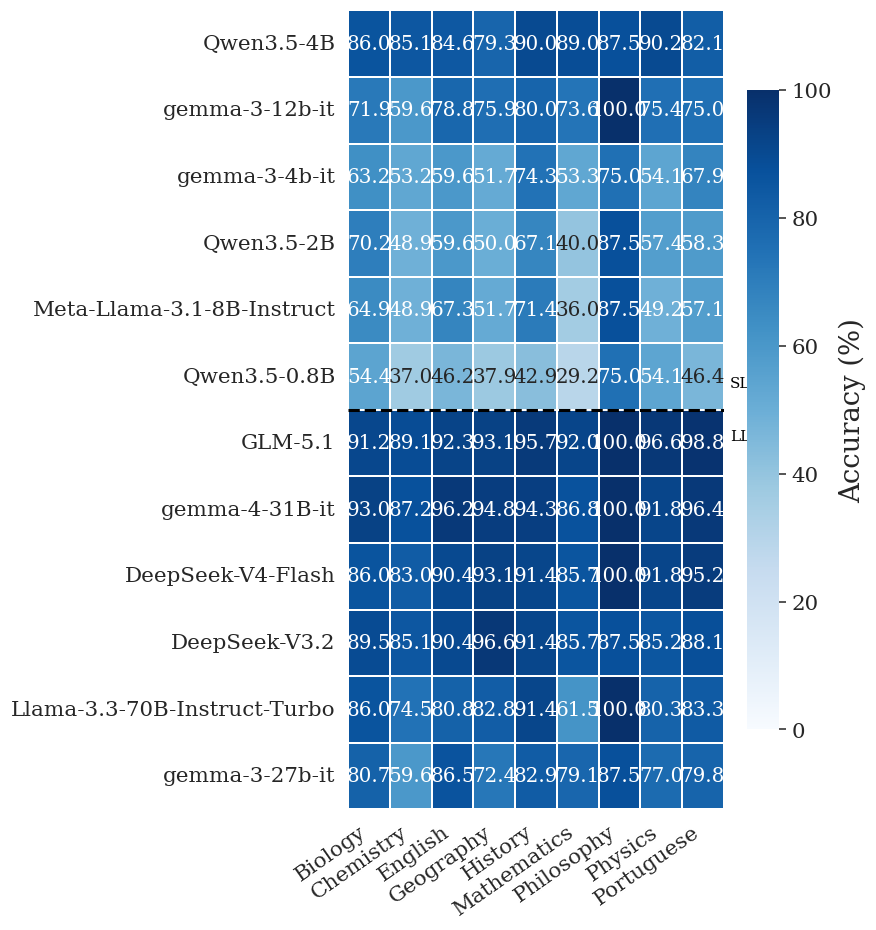

In [21]:
def bluex_subject_pivot_combined() -> pd.DataFrame:
    """Accuracy (%) per (model_short x subject) for FUVEST + Unicamp."""
    datasets = [FUVEST_KEY, UNICAMP_KEY]
    res = RESULTS[RESULTS["dataset"].isin(datasets)][
        ["question_id", "model_short", "is_correct"]
    ]
    if res.empty:
        return pd.DataFrame()
    qs = QUESTIONS[QUESTIONS["dataset"].isin(datasets)][["question_id", "subject"]]
    merged = res.merge(qs, on="question_id", how="inner")
    merged = merged.explode("subject")
    merged = merged[merged["subject"].notna() & (merged["subject"] != "")]
    merged["subject_clean"] = merged["subject"].astype(str).str.title()
    merged = merged.dropna(subset=["is_correct"])
    pivot = (
        merged.groupby(["model_short", "subject_clean"])["is_correct"]
        .mean()
        .unstack("subject_clean") * 100
    )
    order = merged.groupby("model_short")["is_correct"].mean().sort_values(ascending=False).index
    return pivot.reindex(order.intersection(pivot.index))


def _reorder_pivot_slm_then_llm(pivot: pd.DataFrame) -> tuple:
    """Reorder pivot rows: SLMs (sorted by row mean desc) then LLMs (sorted by row mean desc).
    Returns (reordered_pivot, n_slm_rows) for drawing the divider."""
    slm_rows = [idx for idx in pivot.index if is_slm(idx)]
    llm_rows = [idx for idx in pivot.index if not is_slm(idx)]
    slm_means = pivot.loc[slm_rows].mean(axis=1).sort_values(ascending=False)
    llm_means = pivot.loc[llm_rows].mean(axis=1).sort_values(ascending=False)
    ordered = list(slm_means.index) + list(llm_means.index)
    return pivot.reindex(ordered), len(slm_rows)


def plot_subject_heatmap(pivot: pd.DataFrame, title: str, fig_name: str, add_slm_divider: bool = False) -> None:
    if add_slm_divider:
        pivot, n_slm = _reorder_pivot_slm_then_llm(pivot)
    fig_width = min(12.0, max(8.0, 0.6 * pivot.shape[1] + 2.5))
    fig_height = max(6.0, 0.55 * pivot.shape[0] + 2.2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot,
        annot=True,
        annot_kws={"size": 13},
        fmt=".1f",
        cmap="Blues",
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Accuracy (%)", "shrink": 0.8},
        linewidths=0.3,
        linecolor="white",
        ax=ax,
    )
    if add_slm_divider and 0 < n_slm < len(pivot):
        ax.axhline(n_slm, color="black", linewidth=2.0, linestyle="--")
        ax.text(pivot.shape[1] + 0.15, n_slm - 0.4, "SLM", fontsize=10, va="center", color="black")
        ax.text(pivot.shape[1] + 0.15, n_slm + 0.4, "LLM", fontsize=10, va="center", color="black")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=14)
    plt.setp(ax.get_yticklabels(), fontsize=14)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


ENEM_SUBJECT = enem_subject_pivot()
FUVEST_SUBJECT = bluex_subject_pivot(FUVEST_KEY)
UNICAMP_SUBJECT = bluex_subject_pivot(UNICAMP_KEY)
BLUEX_SUBJECT = bluex_subject_pivot_combined()

save_table(ENEM_SUBJECT, "subject_heatmap_enem")
save_table(FUVEST_SUBJECT, "subject_heatmap_fuvest")
save_table(UNICAMP_SUBJECT, "subject_heatmap_unicamp")
save_table(BLUEX_SUBJECT, "subject_heatmap_bluex")

plot_subject_heatmap(ENEM_SUBJECT,    "ENEM \u2014 accuracy (%) by subject",    "subject_heatmap_enem",    add_slm_divider=True)
plot_subject_heatmap(FUVEST_SUBJECT,  "FUVEST \u2014 accuracy (%) by subject",  "subject_heatmap_fuvest",  add_slm_divider=True)
plot_subject_heatmap(UNICAMP_SUBJECT, "Unicamp \u2014 accuracy (%) by subject", "subject_heatmap_unicamp", add_slm_divider=True)

## 6. Per-year evolution

Accuracy per year per model. Solid lines = SLMs; dashed lines = larger reference models. All three datasets are computed from `RESULTS` directly: mean of `is_correct` per `(year, model_short)`.

  saved tables/year_enem.csv  (15 rows)
  saved tables/year_fuvest.csv  (7 rows)
  saved tables/year_unicamp.csv  (6 rows)
  saved figures/year_enem.pdf and figures/year_enem.png


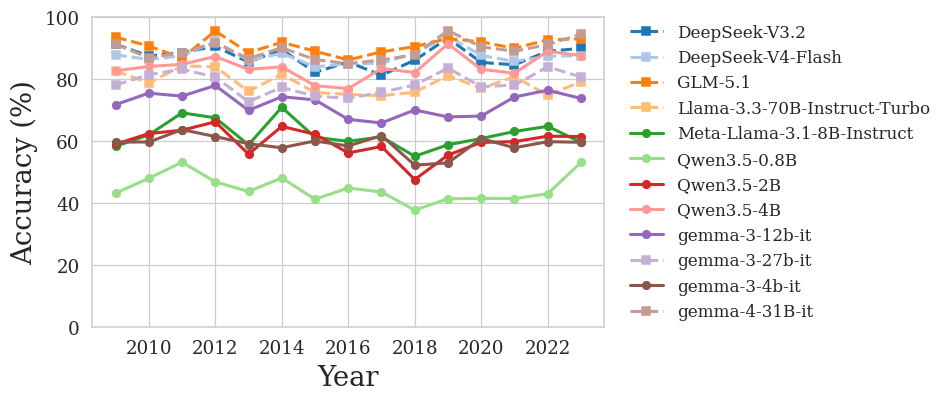

  saved figures/year_fuvest.pdf and figures/year_fuvest.png


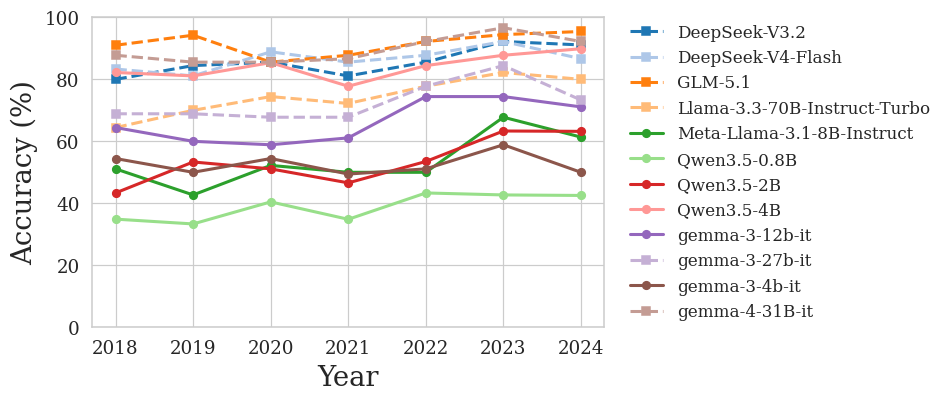

  saved figures/year_unicamp.pdf and figures/year_unicamp.png


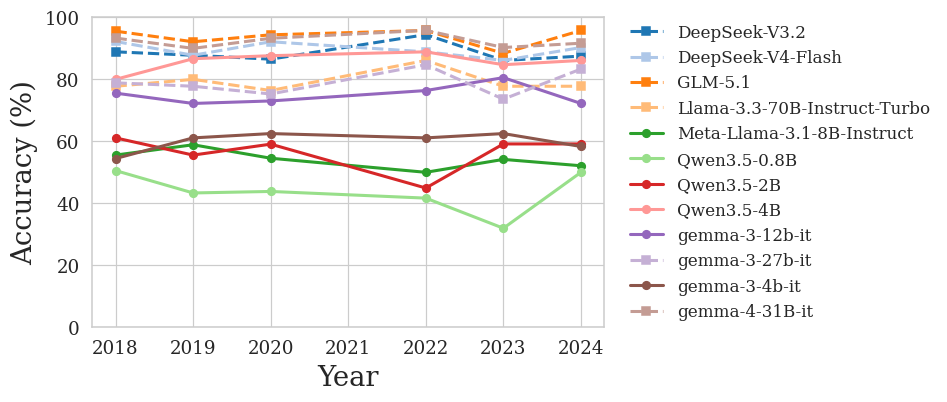

In [13]:
def year_pivot(dataset: str | None) -> pd.DataFrame:
    """Accuracy (%) per (year × model_short) computed from RESULTS."""
    df = RESULTS.copy()
    if dataset is not None:
        df = df[df["dataset"] == dataset]
    df = df.dropna(subset=["is_correct"])
    if df.empty:
        return pd.DataFrame()
    return (
        df.groupby(["year", "model_short"])["is_correct"].mean().unstack("model_short")
        * 100
    )


def enem_year_pivot() -> pd.DataFrame:
    return year_pivot("ENEM")


def bluex_year_pivot(university: str | None) -> pd.DataFrame:
    return year_pivot(university)


def plot_year_lines(pivot: pd.DataFrame, title: str, fig_name: str) -> None:
    fig, ax = plt.subplots(figsize=(9.0, 4.0))
    cmap = plt.get_cmap("tab20")
    columns = list(pivot.columns)
    for i, col in enumerate(columns):
        slm = is_slm(col)
        ax.plot(
            pivot.index,
            pivot[col],
            label=col,
            color=cmap(i % 20),
            linestyle="-" if slm else "--",
            linewidth=2.0,
            marker="o" if slm else "s",
            markersize=5.0,
        )
    ax.set_xlabel("Year")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=11, ncol=1, frameon=False)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


ENEM_YEAR = enem_year_pivot()
FUVEST_YEAR = bluex_year_pivot(FUVEST_KEY)
UNICAMP_YEAR = bluex_year_pivot(UNICAMP_KEY)

save_table(ENEM_YEAR, "year_enem")
save_table(FUVEST_YEAR, "year_fuvest")
save_table(UNICAMP_YEAR, "year_unicamp")

plot_year_lines(ENEM_YEAR,    "ENEM \u2014 accuracy by year",    "year_enem")
plot_year_lines(FUVEST_YEAR,  "FUVEST \u2014 accuracy by year",  "year_fuvest")
plot_year_lines(UNICAMP_YEAR, "Unicamp \u2014 accuracy by year", "year_unicamp")

## 7. Capability and modality analysis

### 7.1 ENEM — image-augmented vs. text-only

ENEM splits questions into `image_augmented` (the SLM was given a VLM-produced description) vs. `text_only`. The gap between the two tells us how much accuracy the SLM loses when it depends on the descriptor.

### 7.2 BLUEX — BNCC capability tags

Each BLUEX question is annotated with binary capability tags. Following BLUEX's README:

- **BK**: Brazilian Knowledge — requires knowledge about Brazil.
- **TU**: Text Understanding.
- **MR**: Mathematical Reasoning.
- **IU**: Image Understanding (the question requires reading an image).
- **ML**: Multilingual question.
- **PRK**: Prior Knowledge.

We compute, for each model and each capability, the accuracy on questions where the tag is **True** vs. **False**, and then `diff = acc_True - acc_False` (positive = the model handles questions requiring this capability *better* than it handles other questions; negative = the capability hurts the model). The pre-computed BLUEX tables (`capability_*_best_descriptor.csv`) are aggregated under the *best* descriptor per model; we re-display those for consistency with the source notebook.

  saved tables/modality_enem.csv  (12 rows)
  saved figures/modality_enem.pdf and figures/modality_enem.png


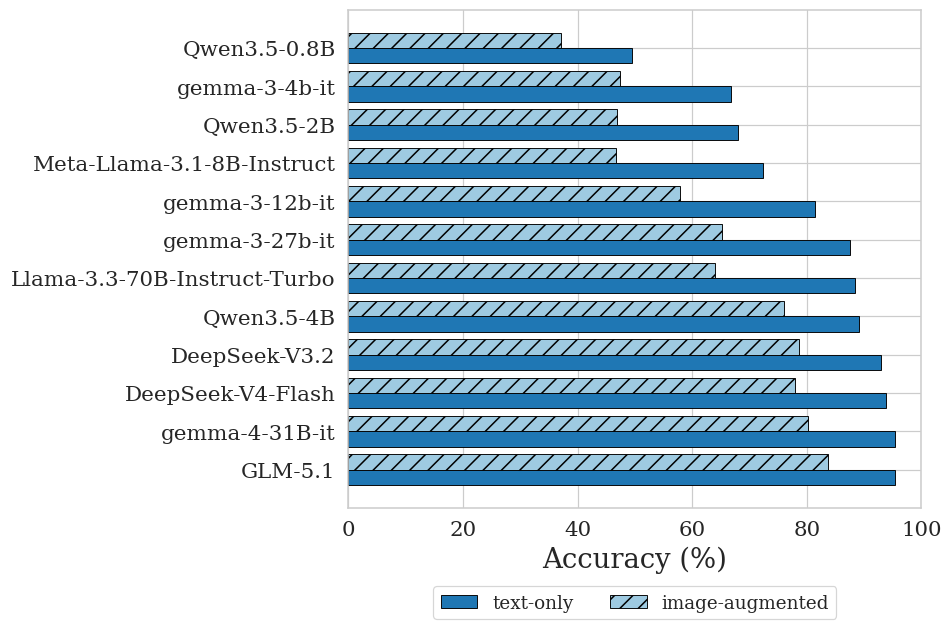

question_modality,image_augmented,text_only,gap (text - image)
model_short,,,
GLM-5.1,83.702213,95.411090,11.708877
gemma-4-31B-it,80.273438,95.353278,15.079841
DeepSeek-V4-Flash,77.929688,93.889243,15.959555
DeepSeek-V3.2,78.669276,92.998090,14.328814
Qwen3.5-4B,76.101861,89.165073,13.063212
Llama-3.3-70B-Instruct-Turbo,64.062500,88.478676,24.416176
gemma-3-27b-it,65.200391,87.523870,22.323479
gemma-3-12b-it,57.910156,81.413113,23.502956
Meta-Llama-3.1-8B-Instruct,46.745562,72.286079,25.540517


In [14]:
def enem_modality_pivot() -> pd.DataFrame:
    """Accuracy (%) per (model_short × text-only/image-augmented) for ENEM."""
    df = RESULTS[RESULTS["dataset"] == "ENEM"].dropna(subset=["is_correct"]).copy()
    if df.empty:
        return pd.DataFrame()
    df["question_modality"] = np.where(df["has_images"], "image_augmented", "text_only")
    pivot = (
        df.pivot_table(
            index="model_short",
            columns="question_modality",
            values="is_correct",
            aggfunc="mean",
        ) * 100
    )
    order = ENEM_OVERALL.set_index("model_short")["accuracy_pct"]
    pivot = pivot.reindex(order.index.intersection(pivot.index))
    pivot["gap (text - image)"] = pivot.get("text_only", np.nan) - pivot.get("image_augmented", np.nan)
    return pivot


ENEM_MODALITY = enem_modality_pivot()
save_table(ENEM_MODALITY, "modality_enem")

fig, ax = plt.subplots(figsize=(9.0, max(3.5, 0.42 * len(ENEM_MODALITY) + 1.5)))
y = np.arange(len(ENEM_MODALITY))
width = 0.4
text_color = SLM_COLOR
image_color = "#9ecae1"
ax.barh(y - width / 2, ENEM_MODALITY["text_only"], width, label="text-only", color=text_color, edgecolor="black", linewidth=0.6)
image_bars = ax.barh(y + width / 2, ENEM_MODALITY["image_augmented"], width, label="image-augmented", color=image_color, edgecolor="black", linewidth=0.6)
for bar in image_bars:
    bar.set_hatch("//")
ax.set_yticks(y)
ax.set_yticklabels(ENEM_MODALITY.index)
ax.set_xlabel("Accuracy (%)")
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=True, fontsize=12)
fig.tight_layout(rect=(0, 0.06, 1, 1))
save_fig(fig, "modality_enem")
plt.show()
ENEM_MODALITY

,meaning
BK,BK — Brazilian Knowledge
TU,TU — Text Understanding
MR,MR — Mathematical Reasoning
IU,IU — Image Understanding
ML,ML — Multilingual
PRK,PRK — Prior Knowledge
CI,CI — Contains Image


  saved tables/capability_true_bluex.csv  (12 rows)
  saved tables/capability_false_bluex.csv  (12 rows)
  saved tables/capability_diff_bluex.csv  (12 rows)
  saved figures/capability_diff_bluex.pdf and figures/capability_diff_bluex.png


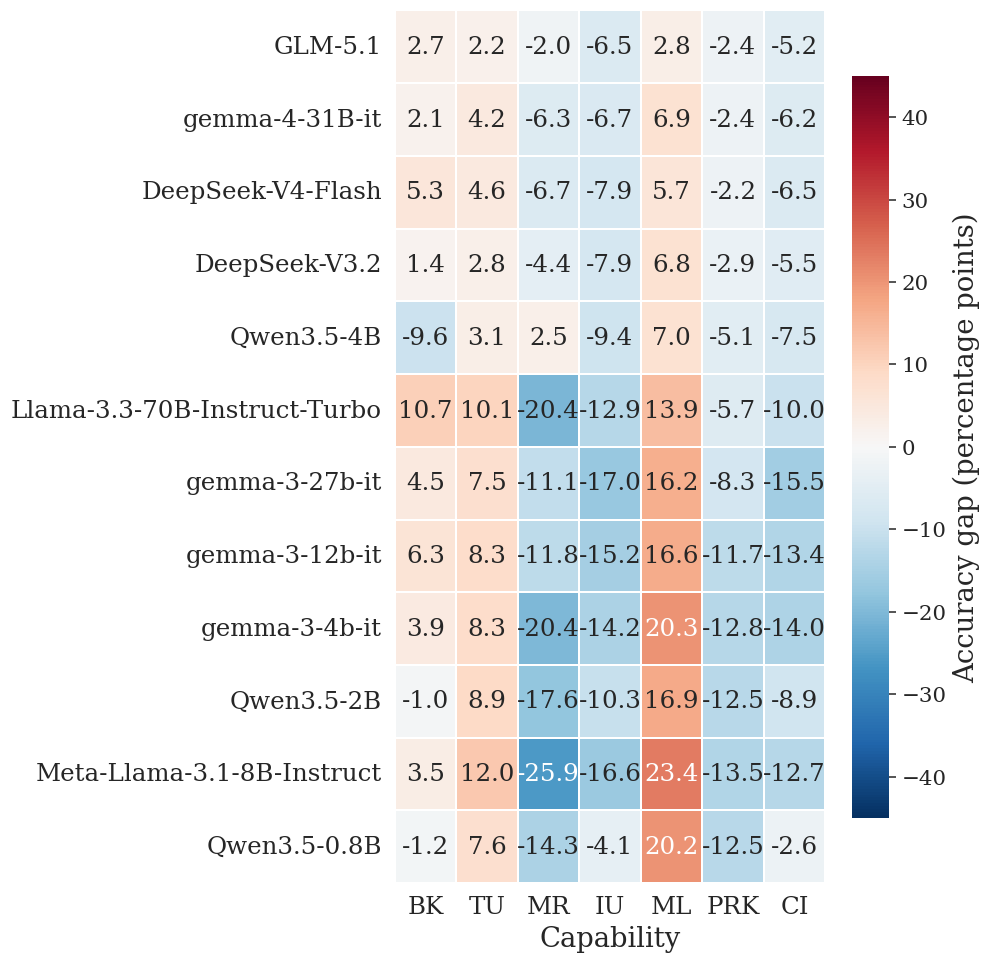

  saved figures/capability_true_bluex.pdf and figures/capability_true_bluex.png


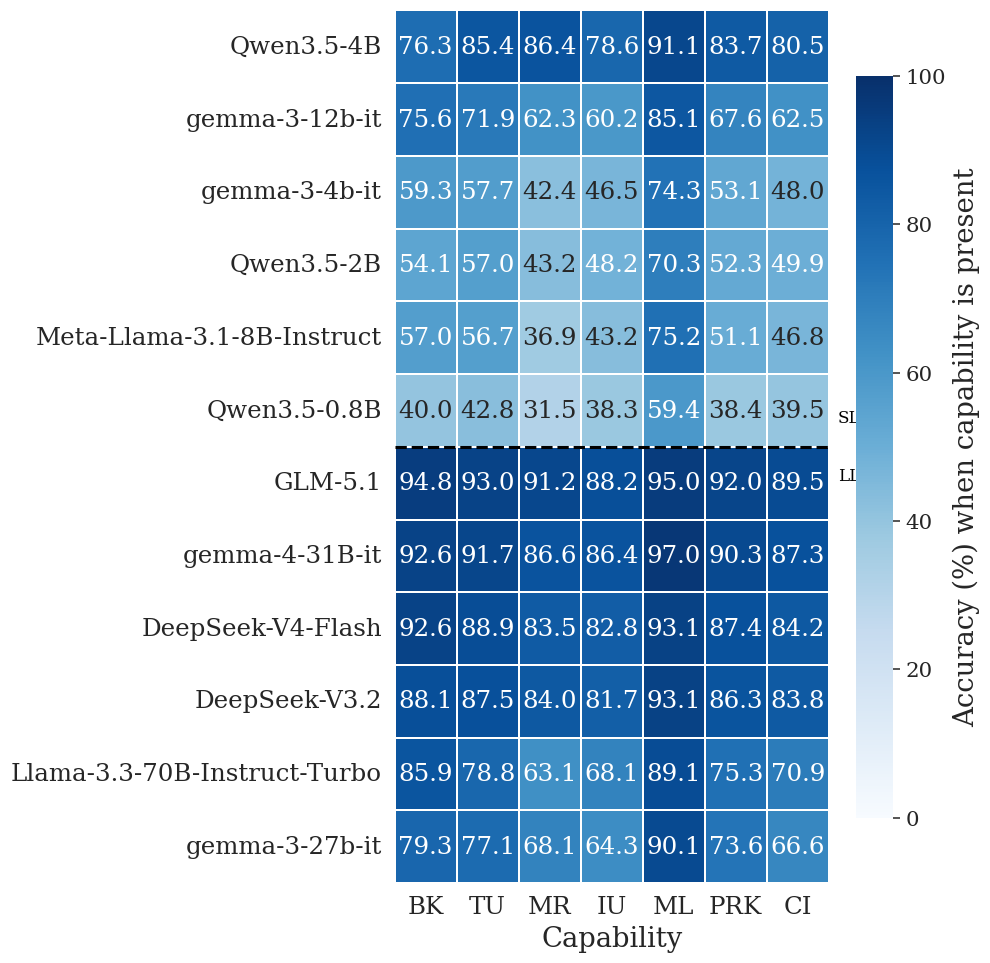

  saved figures/capability_false_bluex.pdf and figures/capability_false_bluex.png


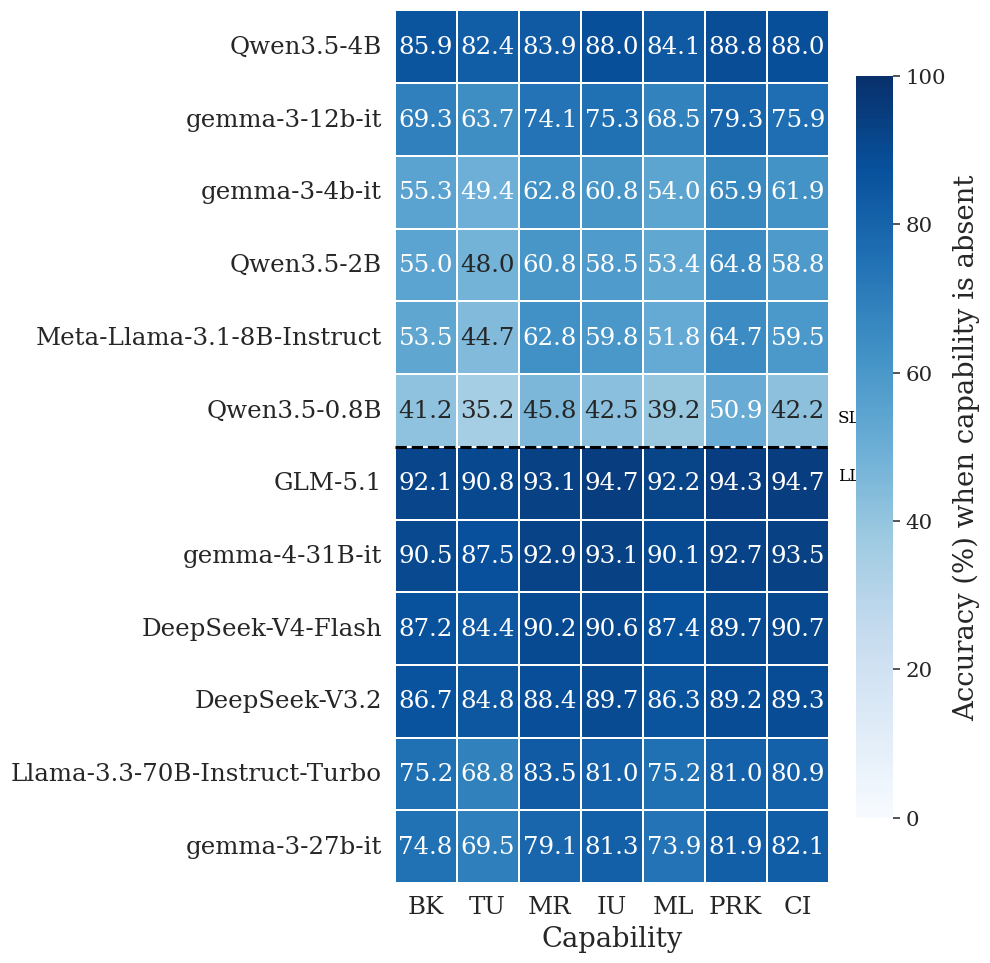

In [20]:
CAPABILITY_LEGEND = {
    "BK":  "BK \u2014 Brazilian Knowledge",
    "TU":  "TU \u2014 Text Understanding",
    "MR":  "MR \u2014 Mathematical Reasoning",
    "IU":  "IU \u2014 Image Understanding",
    "ML":  "ML \u2014 Multilingual",
    "PRK": "PRK \u2014 Prior Knowledge",
    "CI":  "CI \u2014 Contains Image",
}
CAP_FLAGS = ("BK", "TU", "MR", "IU", "ML", "PRK", "CI")

# Compute capability tables directly from RESULTS x QUESTIONS for the BLUEX
# universe (FUVEST + Unicamp). For each capability, we compare accuracy when
# the tag is present with accuracy when the tag is absent.
def _bluex_capability_pivot(flag_value: bool) -> pd.DataFrame:
    qs = QUESTIONS[QUESTIONS["dataset"].isin([FUVEST_KEY, UNICAMP_KEY])]
    res = RESULTS[RESULTS["dataset"].isin([FUVEST_KEY, UNICAMP_KEY])].dropna(subset=["is_correct"])
    merged = res.merge(qs, on="question_id", how="inner", suffixes=("", "_q"))
    rows: dict[str, dict[str, float]] = {}
    for cap in CAP_FLAGS:
        col = f"cap_{cap}"
        if col not in merged.columns:
            continue
        sub = merged[merged[col] == flag_value]
        if sub.empty:
            continue
        per_model = sub.groupby("model_short")["is_correct"].mean() * 100
        for m, val in per_model.items():
            rows.setdefault(m, {})[cap] = float(val)
    return pd.DataFrame(rows).T.reindex(columns=list(CAP_FLAGS))


CAP_TRUE = _bluex_capability_pivot(True)
CAP_FALSE = _bluex_capability_pivot(False)
CAP_DIFF = CAP_TRUE - CAP_FALSE

_bluex_order = (
    RESULTS[RESULTS["dataset"].isin([FUVEST_KEY, UNICAMP_KEY])]
    .dropna(subset=["is_correct"])
    .groupby("model_short")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .index
)
CAP_TRUE = CAP_TRUE.reindex(_bluex_order.intersection(CAP_TRUE.index))
CAP_FALSE = CAP_FALSE.reindex(_bluex_order.intersection(CAP_FALSE.index))
CAP_DIFF = CAP_DIFF.reindex(_bluex_order.intersection(CAP_DIFF.index))

display(pd.DataFrame.from_dict(CAPABILITY_LEGEND, orient="index", columns=["meaning"]))
save_table(CAP_TRUE, "capability_true_bluex")
save_table(CAP_FALSE, "capability_false_bluex")
save_table(CAP_DIFF, "capability_diff_bluex")


def _reorder_cap_slm_then_llm(df: pd.DataFrame) -> tuple:
    """Reorder rows: SLMs then LLMs, each sorted by row mean descending."""
    slm_rows = [idx for idx in df.index if is_slm(idx)]
    llm_rows  = [idx for idx in df.index if not is_slm(idx)]
    slm_means = df.loc[slm_rows].mean(axis=1).sort_values(ascending=False)
    llm_means  = df.loc[llm_rows].mean(axis=1).sort_values(ascending=False)
    ordered = list(slm_means.index) + list(llm_means.index)
    return df.reindex(ordered), len(slm_rows)


def plot_capability_heatmap(df: pd.DataFrame, cmap: str, vmin: float, vmax: float,
                             center, cbar_label: str, fig_name: str,
                             add_slm_divider: bool = False) -> None:
    if add_slm_divider:
        df, n_slm = _reorder_cap_slm_then_llm(df)
    fig, ax = plt.subplots(figsize=(9.0, max(6.5, 0.55 * len(df) + 2.5)))
    sns.heatmap(
        df,
        annot=True,
        annot_kws={"size": 16},
        fmt=".1f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        cbar_kws={"label": cbar_label, "shrink": 0.85},
        linewidths=0.3,
        linecolor="white",
        ax=ax,
    )
    if add_slm_divider and 0 < n_slm < len(df):
        ax.axhline(n_slm, color="black", linewidth=2.0, linestyle="--")
        ax.text(df.shape[1] + 0.15, n_slm - 0.4, "SLM", fontsize=11, va="center", color="black")
        ax.text(df.shape[1] + 0.15, n_slm + 0.4, "LLM", fontsize=11, va="center", color="black")
    ax.set_xlabel("Capability")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=16)
    plt.setp(ax.get_yticklabels(), fontsize=16)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


def plot_capability_diff_heatmap(df: pd.DataFrame) -> None:
    plot_capability_heatmap(df, cmap="RdBu_r", vmin=-45, vmax=45, center=0,
                             cbar_label="Accuracy gap (percentage points)",
                             fig_name="capability_diff_bluex")


plot_capability_diff_heatmap(CAP_DIFF)
plot_capability_heatmap(CAP_TRUE, cmap="Blues", vmin=0, vmax=100, center=None,
                         cbar_label="Accuracy (%) when capability is present",
                         fig_name="capability_true_bluex", add_slm_divider=True)
plot_capability_heatmap(CAP_FALSE, cmap="Blues", vmin=0, vmax=100, center=None,
                         cbar_label="Accuracy (%) when capability is absent",
                         fig_name="capability_false_bluex", add_slm_divider=True)

## 8. Cost-benefit analysis

For each dataset, we plot **USD per 1k questions** (x, log scale) against **accuracy %** (y). SLMs sit on the Pareto frontier when no other model is both cheaper *and* more accurate. We highlight that frontier with a connecting dashed line.

- **ENEM** costs come from `executive_by_model.csv` (`total_cost_usd / tasks_observed * 1000`).
- **BLUEX** costs come from the raw `custo_total` column averaged over all rows per `(modelo, university)`.

  saved tables/cost_benefit_enem.csv  (12 rows)
  saved tables/cost_benefit_fuvest.csv  (12 rows)
  saved tables/cost_benefit_unicamp.csv  (12 rows)
  saved tables/cost_benefit_all.csv  (12 rows)
  saved figures/cost_benefit_all.pdf and figures/cost_benefit_all.png


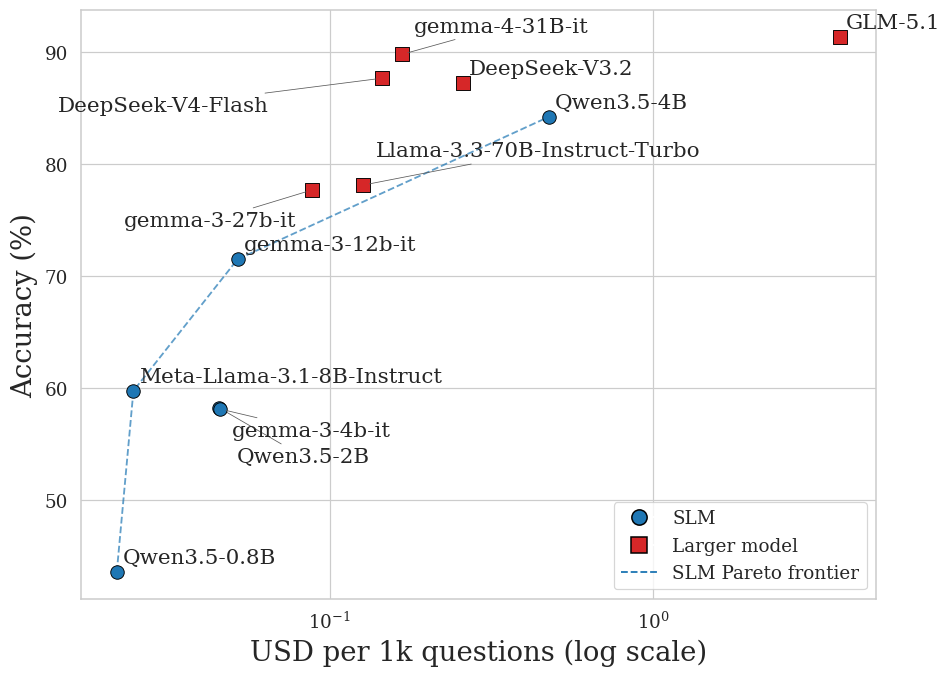

In [22]:
ZERO_COST_PLACEHOLDER = 1e-3


def cost_benefit_table(overall: pd.DataFrame, cost_col: str, n_col: str) -> pd.DataFrame:
    df = overall.copy()
    df["cost_per_1k"] = df[cost_col] / df[n_col].replace(0, np.nan) * 1000
    df["cost_per_1k_plot"] = df["cost_per_1k"].fillna(0).clip(lower=0)
    df.loc[df["cost_per_1k_plot"] <= 0, "cost_per_1k_plot"] = ZERO_COST_PLACEHOLDER
    df["zero_cost"] = df["cost_per_1k"].fillna(0) <= 0
    return df


def aggregate_cost_benefit_tables(*frames: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat(frames, ignore_index=True)
    agg = (
        df.groupby(["modelo", "model_short", "is_slm"], as_index=False)
        .agg(
            n_rows=("n_rows", "sum"),
            n_parsed=("n_parsed", "sum"),
            n_correct=("n_correct", "sum"),
            total_cost_usd=("total_cost_usd", "sum"),
            tasks_observed=("tasks_observed", "sum"),
        )
    )
    agg["accuracy_pct"] = agg["n_correct"] / agg["n_parsed"].replace(0, np.nan) * 100
    agg["cost_per_1k"] = agg["total_cost_usd"] / agg["tasks_observed"].replace(0, np.nan) * 1000
    agg["cost_per_1k_plot"] = agg["cost_per_1k"].fillna(0).clip(lower=0)
    agg.loc[agg["cost_per_1k_plot"] <= 0, "cost_per_1k_plot"] = ZERO_COST_PLACEHOLDER
    agg["zero_cost"] = agg["cost_per_1k"].fillna(0) <= 0
    return agg.sort_values("accuracy_pct", ascending=False).reset_index(drop=True)


def pareto_frontier(df: pd.DataFrame) -> pd.DataFrame:
    pts = df.sort_values(["cost_per_1k_plot", "accuracy_pct"], ascending=[True, False]).reset_index(drop=True)
    keep = []
    best_acc = -np.inf
    for _, r in pts.iterrows():
        if r["accuracy_pct"] > best_acc:
            keep.append(r)
            best_acc = r["accuracy_pct"]
    return pd.DataFrame(keep)


def plot_cost_benefit(df: pd.DataFrame, title: str, fig_name: str) -> None:
    fig, ax = plt.subplots(figsize=(9.0, 6.5))
    label_offsets = {
        "Qwen3.5-2B": (12, -26),
        "gemma-3-4b-it": (8, -8),
        "Llama-3.3-70B-Instruct-Turbo": (8, 16),
        "gemma-3-27b-it": (-10, -14),
        "gemma-4-31B-it": (8, 12),
        "DeepSeek-V4-Flash": (-74, -12),
    }
    for _, r in df.iterrows():
        marker = "o" if r["is_slm"] else "s"
        color = SLM_COLOR if r["is_slm"] else LARGE_COLOR
        xy = (r["cost_per_1k_plot"], r["accuracy_pct"])
        ax.scatter(*xy, s=78, marker=marker, color=color, edgecolor="black", linewidth=0.6, zorder=3)
        xytext = label_offsets.get(r["model_short"], (4, 3))
        needs_arrow = r["model_short"] in label_offsets
        ax.annotate(
            r["model_short"],
            xy=xy,
            xytext=xytext,
            textcoords="offset points",
            fontsize=14,
            ha="right" if xytext[0] < 0 else "left",
            va="bottom" if xytext[1] >= 0 else "top",
            arrowprops={"arrowstyle": "-", "lw": 0.5, "color": "0.35", "shrinkA": 0, "shrinkB": 4} if needs_arrow else None,
        )
    front = pareto_frontier(df[df["is_slm"]])
    if len(front) >= 2:
        ax.plot(front["cost_per_1k_plot"], front["accuracy_pct"], linestyle="--", color=SLM_COLOR, alpha=0.7, label="SLM Pareto frontier", zorder=2)
    ax.set_xscale("log")
    ax.set_xlabel("USD per 1k questions (log scale)")
    ax.set_ylabel("Accuracy (%)")
    ax.tick_params(axis="both", labelsize=12)
    slm_handle = plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=SLM_COLOR, markeredgecolor="black", markersize=10, label="SLM")
    large_handle = plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=LARGE_COLOR, markeredgecolor="black", markersize=10, label="Larger model")
    front_handle = plt.Line2D([0], [0], linestyle="--", color=SLM_COLOR, label="SLM Pareto frontier")
    ax.legend(handles=[slm_handle, large_handle, front_handle], loc="lower right", fontsize=12)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


ENEM_CB    = cost_benefit_table(ENEM_OVERALL,    "total_cost_usd", "tasks_observed")
FUVEST_CB  = cost_benefit_table(FUVEST_OVERALL,  "total_cost",     "n_rows")
UNICAMP_CB = cost_benefit_table(UNICAMP_OVERALL, "total_cost",     "n_rows")
ALL_CB = aggregate_cost_benefit_tables(ENEM_CB, FUVEST_CB, UNICAMP_CB)

save_table(ENEM_CB,    "cost_benefit_enem")
save_table(FUVEST_CB,  "cost_benefit_fuvest")
save_table(UNICAMP_CB, "cost_benefit_unicamp")
save_table(ALL_CB,     "cost_benefit_all")

plot_cost_benefit(ALL_CB, "ENEM + FUVEST + Unicamp \u2014 cost vs. accuracy", "cost_benefit_all")

## 9. VLM descriptor sensitivity (simplified)

In the previous iteration of this work we ran the full SLM × descriptor cross-product to study descriptor sensitivity (see `BLUEX/descriptions_analysis/tables/descriptor_ranking.csv`). For this paper we standardise on **ByteDance Seed-1.8** as the sole VLM descriptor (best mean accuracy in that earlier sweep), so descriptor sensitivity is a constant by construction here. The historical descriptor-ranking and per-SLM-spread tables are cited in the discussion section but no longer regenerated by this notebook.

In [14]:
# Descriptor sensitivity is a constant in this run (one descriptor: Seed-1.8).
# The per-SLM × per-descriptor heatmap and ranking are no longer regenerated.
print("Section 9: single-descriptor (Seed-1.8) run; nothing to plot.")

Section 9: single-descriptor (Seed-1.8) run; nothing to plot.


In [15]:
# (intentionally empty: descriptor sensitivity collapses with one descriptor)

In [16]:
# (intentionally empty)

## 10. Cross-dataset summary

One row per model with `acc_ENEM`, `acc_FUVEST`, `acc_UNICAMP`, their mean, the `is_slm` flag and parameter count. Models that were not evaluated on a given dataset show `NaN` in that column.

## 11. Best-SLM spotlight

For each dataset we report the best SLM, the best larger model and the gap between the two — handy single-sentence numbers for the paper.

In [17]:
def _per_dataset_series(df: pd.DataFrame, label: str) -> pd.Series:
    return df.set_index("modelo")["accuracy_pct"].rename(f"acc_{label}")


CROSS = (
    MODEL_DF.set_index("modelo")[["short", "is_slm", "params_b", "moe"]]
    .join(_per_dataset_series(ENEM_OVERALL,    "ENEM"),    how="left")
    .join(_per_dataset_series(FUVEST_OVERALL,  "FUVEST"),  how="left")
    .join(_per_dataset_series(UNICAMP_OVERALL, "UNICAMP"), how="left")
)
CROSS["mean_acc"] = CROSS[["acc_ENEM", "acc_FUVEST", "acc_UNICAMP"]].mean(axis=1)
CROSS = CROSS.sort_values(["is_slm", "mean_acc"], ascending=[False, False])
save_table(CROSS, "cross_dataset_summary")
CROSS.round(2)

  saved tables/cross_dataset_summary.csv  (12 rows)


,short,is_slm,params_b,moe,acc_ENEM,acc_FUVEST,acc_UNICAMP,mean_acc
modelo,,,,,,,,
Qwen/Qwen3.5-4B,Qwen3.5-4B,True,4.0,False,84.02,84.08,85.57,84.55
google/gemma-3-12b-it,gemma-3-12b-it,True,12.0,False,72.14,66.35,74.85,71.11
google/gemma-3-4b-it,gemma-3-4b-it,True,4.0,False,59.14,52.62,59.92,57.23
meta-llama/Meta-Llama-3.1-8B-Instruct,Meta-Llama-3.1-8B-Instruct,True,8.0,False,62.25,53.59,54.45,56.76
Qwen/Qwen3.5-2B,Qwen3.5-2B,True,2.0,False,59.69,53.46,56.78,56.65
Qwen/Qwen3.5-0.8B,Qwen3.5-0.8B,True,0.8,True,44.68,38.87,43.78,42.44
zai-org/GLM-5.1,GLM-5.1,False,754.0,True,90.87,91.51,93.74,92.04
google/gemma-4-31B-it,gemma-4-31B-it,False,31.0,False,89.40,89.52,92.37,90.43
deepseek-ai/DeepSeek-V4-Flash,DeepSeek-V4-Flash,False,284.0,True,87.59,86.51,89.69,87.93


  saved figures/cross_dataset_grouped.pdf and figures/cross_dataset_grouped.png


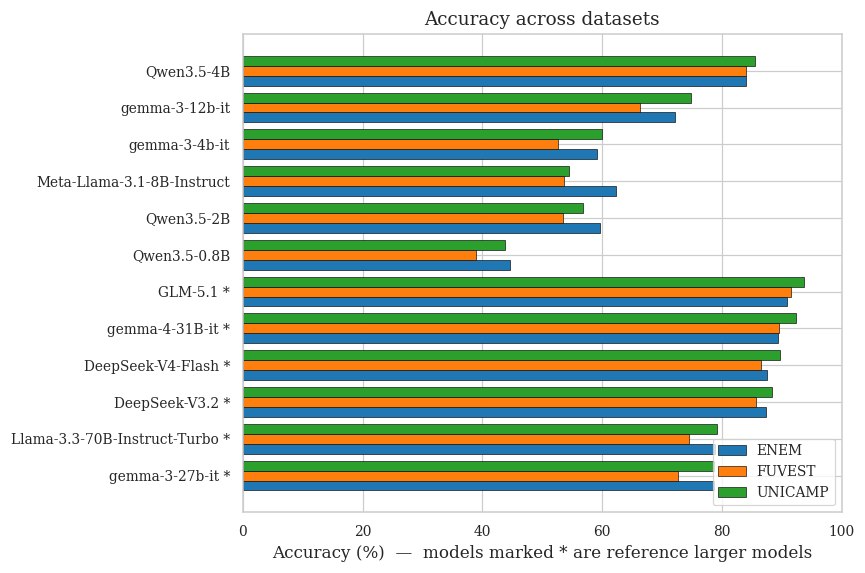

In [18]:
def grouped_bar(df: pd.DataFrame, value_cols: list[str], title: str, fig_name: str) -> None:
    df = df.dropna(subset=value_cols, how="all").copy()
    df["sort_key"] = df[value_cols].mean(axis=1)
    df = df.sort_values(["is_slm", "sort_key"], ascending=[True, True])
    n = len(df)
    fig, ax = plt.subplots(figsize=(10.0, max(4.0, 0.42 * n + 1.8)))
    y = np.arange(n)
    width = 0.27
    palette = {"acc_ENEM": "#1f77b4", "acc_FUVEST": "#ff7f0e", "acc_UNICAMP": "#2ca02c"}
    for i, col in enumerate(value_cols):
        ax.barh(y + (i - 1) * width, df[col].values, height=width, color=palette[col], label=col.replace("acc_", ""), edgecolor="black", linewidth=0.4)
    ax.set_yticks(y)
    labels = [f"{s}{'' if slm else ' *'}" for s, slm in zip(df["short"], df["is_slm"])]
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Accuracy (%)  \u2014  models marked * are reference larger models")
    ax.legend(loc="lower right", fontsize=12)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


grouped_bar(CROSS.reset_index(), ["acc_ENEM", "acc_FUVEST", "acc_UNICAMP"], "Accuracy across datasets", "cross_dataset_grouped")

In [19]:
def spotlight_row(df: pd.DataFrame, label: str) -> dict:
    df = df.dropna(subset=["accuracy_pct"]).copy()
    if df.empty:
        return {"dataset": label}
    slms = df[df["is_slm"]]
    larges = df[~df["is_slm"]]
    best_slm = slms.sort_values("accuracy_pct", ascending=False).head(1).iloc[0] if len(slms) else None
    best_large = larges.sort_values("accuracy_pct", ascending=False).head(1).iloc[0] if len(larges) else None
    return {
        "dataset": label,
        "best_slm": best_slm["model_short"] if best_slm is not None else None,
        "best_slm_acc": round(best_slm["accuracy_pct"], 2) if best_slm is not None else None,
        "best_large": best_large["model_short"] if best_large is not None else None,
        "best_large_acc": round(best_large["accuracy_pct"], 2) if best_large is not None else None,
        "gap_pp": round(best_large["accuracy_pct"] - best_slm["accuracy_pct"], 2) if (best_slm is not None and best_large is not None) else None,
    }


SPOTLIGHT = pd.DataFrame([
    spotlight_row(ENEM_OVERALL,    "ENEM"),
    spotlight_row(FUVEST_OVERALL,  "FUVEST"),
    spotlight_row(UNICAMP_OVERALL, "Unicamp"),
]).set_index("dataset")
save_table(SPOTLIGHT, "best_slm_spotlight")
SPOTLIGHT

  saved tables/best_slm_spotlight.csv  (3 rows)


,best_slm,best_slm_acc,best_large,best_large_acc,gap_pp
dataset,,,,,
ENEM,Qwen3.5-4B,84.02,GLM-5.1,90.87,6.85
FUVEST,Qwen3.5-4B,84.08,GLM-5.1,91.51,7.43
Unicamp,Qwen3.5-4B,85.57,GLM-5.1,93.74,8.17


## 12. Failure analysis

We track several distinct failure modes from the SQLite results table:

- `parse_status` breakdown per model (the proportion of `ok` / `truncated_but_answered` / `json_error` / `disallowed_value` / `empty` / `provider_rejected` / `cost_cap_reached` / `model_unavailable` rows).
- Empty-answer rate per `(dataset, model)` pair: rows where `parsed_answer IS NULL` despite no terminal failure.
- Models the API never served (`parse_status="model_unavailable"` for every pair) — listed explicitly so the leaderboard is honest about coverage.
- The `finish_reason="length" × parsed_answer IS NULL` bucket: the model spent its entire output budget on hidden reasoning tokens and emitted no visible answer. Distinct from JSON parse failures and treated as a model-capability signal in the discussion.
- Smoke-test contamination: rows whose `run_id` differs from the production run id. Expected: ≤ 30 rows on the 3 plan-2 smoke models.
- Excluded questions: 9 IDs (8 ENEM, 1 BLUEX) dropped up-front for unrecoverable images or sensitive content. They never appear in `RESULTS`, so all aggregates above are automatically consistent. The canonical list lives in `experiments/config.py`.rce repo — only models whose endpoint occasionally failed appear here.

BLUEX raw CSVs include an `error` column; we report per-model error counts inferred from non-empty `error` rows.

  saved tables/parse_status_per_model.csv  (12 rows)


parse_status,disallowed_value,disallowed_value_from_reasoning_content,empty,json_error,json_error_from_reasoning_content,ok,ok_from_reasoning_content,truncated_but_answered,truncated_but_answered_from_reasoning_content
model_short,,,,,,,,,
DeepSeek-V3.2,1,0,2,0,0,3707,0,0,0
DeepSeek-V4-Flash,1,0,0,0,0,3709,0,0,0
GLM-5.1,1,0,1,0,43,3533,124,7,1
Llama-3.3-70B-Instruct-Turbo,1,0,0,0,0,3703,0,6,0
Meta-Llama-3.1-8B-Instruct,2,0,20,0,0,3638,0,50,0
Qwen3.5-0.8B,0,4,0,0,41,0,3657,0,8
Qwen3.5-2B,0,4,0,0,40,0,3629,0,37
Qwen3.5-4B,1,0,0,0,7,3693,2,5,2
gemma-3-12b-it,2,0,0,0,0,3534,0,174,0


  saved figures/parse_status_per_model.pdf and figures/parse_status_per_model.png


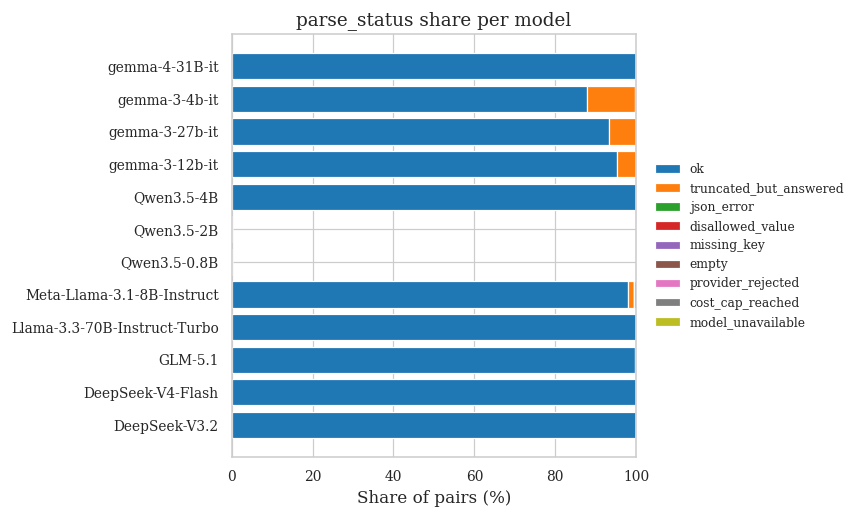

  saved tables/empty_answer_rate.csv  (36 rows)


empty_rows  total_rows  empty_pct
dataset model_short                                                  
FUVEST  Qwen3.5-0.8B                        10         630      1.587
        Qwen3.5-2B                           9         630      1.429
UNICAMP GLM-5.1                              6         485      1.237
        Qwen3.5-2B                           6         485      1.237
ENEM    GLM-5.1                             32        2595      1.233
        Qwen3.5-0.8B                        28        2595      1.079
        Qwen3.5-2B                          25        2595      0.963
FUVEST  GLM-5.1                              6         630      0.952
UNICAMP Qwen3.5-0.8B                         3         485      0.619
ENEM    Meta-Llama-3.1-8B-Instruct          15        2595      0.578
FUVEST  Meta-Llama-3.1-8B-Instruct           3         630      0.476
UNICAMP Meta-Llama-3.1-8B-Instruct           2         485      0.412
FUVEST  Qwen3.5-4B                           2         630      0.317
ENEM    gemma-3-4b-it                        8        2595      0.308
UNICAMP gemma-3-4b-it                        1         485      0.206
ENEM    Qwen3.5-4B                           5        2595      0.193
FUVEST  gemma-3-4b-it                        1         630      0.159
ENEM    DeepSeek-V3.2                        2        2595      0.077
        gemma-3-27b-it                       1        2595      0.039
        DeepSeek-V4-Flash                    0        2595      0.000

Models the API never served (model_unavailable for every pair): []
  saved tables/length_no_answer_per_model.csv  (12 rows)


,length_no_answer,total_rows,length_no_answer_pct
model_short,,,
GLM-5.1,43,3710,1.159
Qwen3.5-0.8B,41,3710,1.105
Qwen3.5-2B,40,3710,1.078
Qwen3.5-4B,7,3710,0.189
DeepSeek-V3.2,0,3710,0.000
DeepSeek-V4-Flash,0,3710,0.000
Llama-3.3-70B-Instruct-Turbo,0,3710,0.000
Meta-Llama-3.1-8B-Instruct,0,3710,0.000
gemma-3-12b-it,0,3710,0.000


  saved tables/finish_reason_per_model.csv  (12 rows)


  saved figures/finish_reason_per_model.pdf and figures/finish_reason_per_model.png


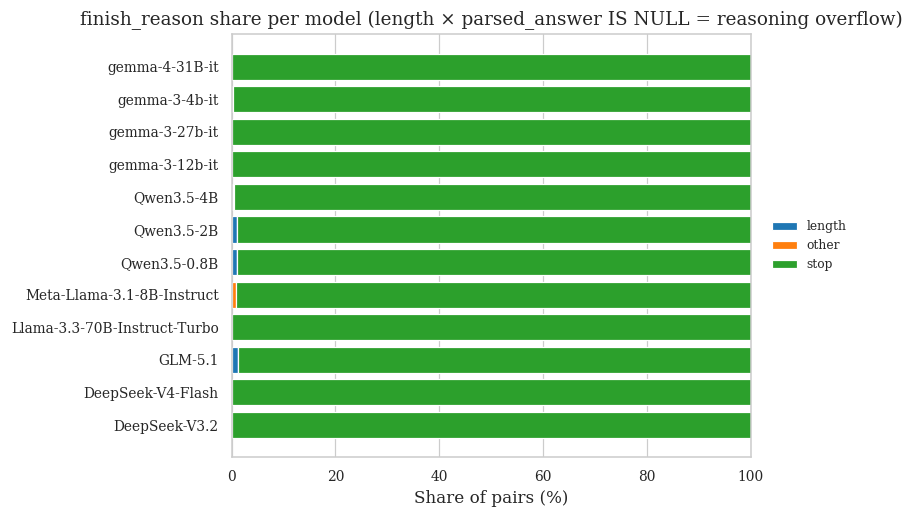

  saved tables/smoke_contamination_per_model.csv  (12 rows)
Production run id: 20260427T114347Z


,non_production_rows,total_rows
model_short,,
DeepSeek-V3.2,904,3710
DeepSeek-V4-Flash,902,3710
GLM-5.1,3710,3710
Llama-3.3-70B-Instruct-Turbo,899,3710
Meta-Llama-3.1-8B-Instruct,943,3710
Qwen3.5-0.8B,3710,3710
Qwen3.5-2B,3710,3710
Qwen3.5-4B,895,3710
gemma-3-12b-it,902,3710


  saved tables/excluded_questions.csv  (9 rows)


,dataset,id,reason
0,ENEM,2022/117,image unrecoverable (Descomplica HTML / zero-b...
1,ENEM,2023/1,image unrecoverable (Descomplica HTML / zero-b...
2,ENEM,2023/5,image unrecoverable (Descomplica HTML / zero-b...
3,ENEM,2023/27,image unrecoverable (Descomplica HTML / zero-b...
4,ENEM,2023/77,image unrecoverable (Descomplica HTML / zero-b...
5,ENEM,2023/86,image unrecoverable (Descomplica HTML / zero-b...
6,ENEM,2023/116,image unrecoverable (Descomplica HTML / zero-b...
7,ENEM,2023/119,image unrecoverable (Descomplica HTML / zero-b...
8,BLUEX,UNICAMP_2020_81,Seed-1.8 SensitiveContentDetected


In [20]:
# --- 12.1 parse_status breakdown per model -------------------------------
PARSE_STATUS_BY_MODEL = (
    RESULTS.groupby(["model_short", "parse_status"])
    .size()
    .unstack("parse_status", fill_value=0)
    .sort_index()
)
save_table(PARSE_STATUS_BY_MODEL, "parse_status_per_model")
display(PARSE_STATUS_BY_MODEL)

# Stacked-bar figure: parse_status_per_model (sanity check that the new
# prompt fixed the old truncation issue).
_PARSE_STATUS_ORDER = [
    "ok",
    "truncated_but_answered",
    "json_error",
    "disallowed_value",
    "missing_key",
    "empty",
    "provider_rejected",
    "cost_cap_reached",
    "model_unavailable",
]
_pivot_n = PARSE_STATUS_BY_MODEL.reindex(columns=_PARSE_STATUS_ORDER, fill_value=0)
_pct = _pivot_n.div(_pivot_n.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, ax = plt.subplots(figsize=(8.0, max(3.0, 0.32 * len(_pct) + 1.0)))
left = np.zeros(len(_pct))
cmap = plt.get_cmap("tab10")
for i, col in enumerate(_pct.columns):
    ax.barh(_pct.index, _pct[col].fillna(0), left=left, color=cmap(i % 10), edgecolor="white", label=col)
    left += _pct[col].fillna(0).to_numpy()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of pairs (%)")
ax.set_title("parse_status share per model")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.tight_layout()
save_fig(fig, "parse_status_per_model")
plt.show()

# --- 12.2 empty-answer rate per (dataset, model) -------------------------
EMPTY_RATE = (
    RESULTS.assign(empty=RESULTS["parsed_answer"].isna()
                   & ~RESULTS["parse_status"].isin(["model_unavailable", "cost_cap_reached", "provider_rejected"]))
    .groupby(["dataset", "model_short"])["empty"]
    .agg(["sum", "size"])
    .rename(columns={"sum": "empty_rows", "size": "total_rows"})
)
EMPTY_RATE["empty_pct"] = (EMPTY_RATE["empty_rows"] / EMPTY_RATE["total_rows"] * 100).round(3)
save_table(EMPTY_RATE, "empty_answer_rate")
display(EMPTY_RATE.sort_values("empty_pct", ascending=False).head(20))

# --- 12.3 dropped models -------------------------------------------------
def _dropped_models() -> list[str]:
    out: list[str] = []
    for model_name, sub in RESULTS.groupby("model"):
        if (sub["parse_status"] == "model_unavailable").all() and len(sub) > 0:
            out.append(model_name)
    return out


DROPPED_MODELS = _dropped_models()
print(f"Models the API never served (model_unavailable for every pair): {DROPPED_MODELS}")

# --- 12.4 reasoning-overflow: finish_reason=length AND parsed_answer IS NULL
LENGTH_NO_ANSWER = (
    RESULTS.assign(
        is_length_overflow=(RESULTS.get("finish_reason") == "length")
                           & RESULTS["parsed_answer"].isna()
    )
    .groupby("model_short")["is_length_overflow"]
    .agg(["sum", "size"])
    .rename(columns={"sum": "length_no_answer", "size": "total_rows"})
)
LENGTH_NO_ANSWER["length_no_answer_pct"] = (
    LENGTH_NO_ANSWER["length_no_answer"] / LENGTH_NO_ANSWER["total_rows"] * 100
).round(3)
LENGTH_NO_ANSWER = LENGTH_NO_ANSWER.sort_values("length_no_answer_pct", ascending=False)
save_table(LENGTH_NO_ANSWER, "length_no_answer_per_model")
display(LENGTH_NO_ANSWER.head(20))

# --- 12.5 finish_reason stacked bar -------------------------------------
FINISH_REASON_BY_MODEL = (
    RESULTS.assign(finish_bucket=RESULTS.get("finish_reason").fillna("other"))
    .groupby(["model_short", "finish_bucket"])
    .size()
    .unstack("finish_bucket", fill_value=0)
)
save_table(FINISH_REASON_BY_MODEL, "finish_reason_per_model")
_finish_pct = FINISH_REASON_BY_MODEL.div(
    FINISH_REASON_BY_MODEL.sum(axis=1).replace(0, np.nan), axis=0
) * 100
fig, ax = plt.subplots(figsize=(8.0, max(3.0, 0.32 * len(_finish_pct) + 1.0)))
left = np.zeros(len(_finish_pct))
for i, col in enumerate(_finish_pct.columns):
    ax.barh(_finish_pct.index, _finish_pct[col].fillna(0), left=left,
            color=cmap(i % 10), edgecolor="white", label=col)
    left += _finish_pct[col].fillna(0).to_numpy()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of pairs (%)")
ax.set_title("finish_reason share per model (length \u00d7 parsed_answer IS NULL = reasoning overflow)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.tight_layout()
save_fig(fig, "finish_reason_per_model")
plt.show()

# --- 12.6 smoke-test contamination per model ----------------------------
if PRODUCTION_RUN_ID is not None:
    contamination = (
        RESULTS.assign(is_other_run=RESULTS["run_id"].fillna("") != PRODUCTION_RUN_ID)
        .groupby("model_short")["is_other_run"]
        .agg(["sum", "size"])
        .rename(columns={"sum": "non_production_rows", "size": "total_rows"})
    )
    contamination = contamination[contamination["non_production_rows"] > 0]
    save_table(contamination, "smoke_contamination_per_model")
    print(f"Production run id: {PRODUCTION_RUN_ID}")
    if not contamination.empty:
        display(contamination)
    else:
        print("No smoke-test contamination detected.")

# --- 12.7 excluded questions --------------------------------------------
EXCLUDED = []
for (year, num) in sorted(_exp_config.ENEM_EXCLUDED_QUESTIONS):
    EXCLUDED.append({"dataset": "ENEM", "id": f"{year}/{num}", "reason": "image unrecoverable (Descomplica HTML / zero-byte / mistyped extension)"})
for qid in sorted(_exp_config.BLUEX_EXCLUDED_QUESTIONS):
    EXCLUDED.append({"dataset": "BLUEX", "id": qid, "reason": "Seed-1.8 SensitiveContentDetected"})
EXCLUDED_DF = pd.DataFrame(EXCLUDED)
save_table(EXCLUDED_DF, "excluded_questions")
display(EXCLUDED_DF)

## 13. Artifacts appendix

Every figure (PDF + PNG) and every table (CSV) produced by this notebook, listed for easy LaTeX wiring.

In [21]:
artifacts = []
for f in sorted(FIGURES_DIR.glob("*.pdf")):
    artifacts.append({"kind": "figure", "name": f.stem, "path": f"figures/{f.name}"})
for f in sorted(TABLES_DIR.glob("*.csv")):
    artifacts.append({"kind": "table",  "name": f.stem, "path": f"tables/{f.name}"})

ARTIFACTS = pd.DataFrame(artifacts)
print(f"Total artifacts: {len(ARTIFACTS)}  ({(ARTIFACTS['kind'] == 'figure').sum()} figures, {(ARTIFACTS['kind'] == 'table').sum()} tables)")
ARTIFACTS

Total artifacts: 44  (19 figures, 25 tables)


,kind,name,path
0,figure,capability_diff_bluex,figures/capability_diff_bluex.pdf
1,figure,capability_false_bluex,figures/capability_false_bluex.pdf
2,figure,capability_true_bluex,figures/capability_true_bluex.pdf
3,figure,cost_benefit_enem,figures/cost_benefit_enem.pdf
4,figure,cost_benefit_fuvest,figures/cost_benefit_fuvest.pdf
5,figure,cost_benefit_unicamp,figures/cost_benefit_unicamp.pdf
6,figure,cross_dataset_grouped,figures/cross_dataset_grouped.pdf
7,figure,finish_reason_per_model,figures/finish_reason_per_model.pdf
8,figure,modality_enem,figures/modality_enem.pdf
9,figure,overall_accuracy_enem,figures/overall_accuracy_enem.pdf
